In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("✅ Библиотеки импортированы")

✅ Библиотеки импортированы


In [2]:
# Путь к данным
RAW_DATA_PATH = Path(r"C:\Users\User\Documents\MyPetProjects\fintech-case\data\raw")

# Загрузка
df = pd.read_csv(RAW_DATA_PATH / "Bank Customer Churn Prediction.csv")
print(f"✅ Загружено {len(df)} строк, {len(df.columns)} столбцов")
print(f"\n📋 Столбцы: {df.columns.tolist()}")

✅ Загружено 10000 строк, 12 столбцов

📋 Столбцы: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


In [3]:
# Первые 5 строк
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
# Описательная статистика
df.describe().round(2)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [6]:
for i in ['credit_card', 'active_member', 'products_number', 'country', 'tenure']:
    print(df[i].value_counts(), end='\n\n')

credit_card
1    7055
0    2945
Name: count, dtype: int64

active_member
1    5151
0    4849
Name: count, dtype: int64

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64



📊 Распределение целевой переменной 'churn':
        Статус  Количество  Процент
0  Не ушёл (0)        7963    79.63
1     Ушёл (1)        2037    20.37

💔 Общий Churn Rate: 20.37%


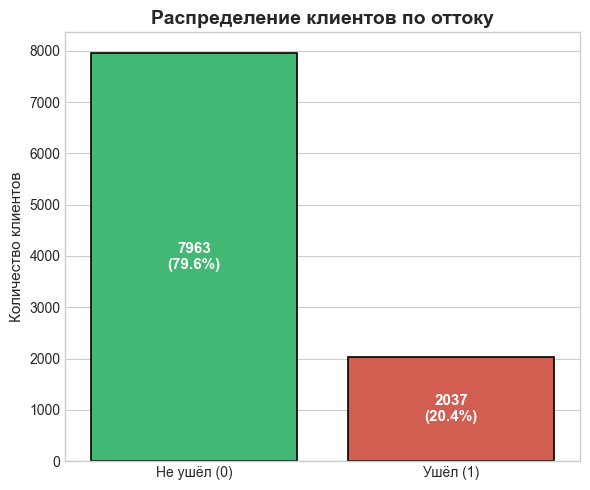

In [7]:
# Распределение целевой переменной
churn_counts = df['churn'].value_counts()
churn_rate = df['churn'].mean() * 100

# Визуализация
plot_data = pd.DataFrame({
    'Статус': ['Не ушёл (0)', 'Ушёл (1)'],           # Подписи для оси X
    'Количество': churn_counts.values,                # Значения для оси Y
    'Процент': churn_counts.values / len(df) * 100    # Доля в процентах для подписей
})

print(f"📊 Распределение целевой переменной 'churn':")
print(plot_data)
print(f"\n💔 Общий Churn Rate: {churn_rate:.2f}%")

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=plot_data,
    x='Статус',
    y='Количество',
    palette=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    linewidth=1.2
)

plt.title('Распределение клиентов по оттоку', fontweight='bold', fontsize=14)
plt.ylabel('Количество клиентов', fontsize=11)
plt.xlabel('')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for i, (count, pct) in enumerate(zip(plot_data['Количество'], plot_data['Процент'])): 
    ax.text(
        x=i,
        y=count / 2,
        s=f'{count}\n({pct:.1f}%)',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

plt.tight_layout()
plt.show()

In [8]:
CLEANED_DATA_PATH = Path(r"C:\Users\User\Documents\MyPetProjects\fintech-case\data\processed")

# Сохраняем очищенный df
df.to_csv(CLEANED_DATA_PATH / "customers_clean.csv", index=False)
print("✅ Данные сохранены в data/processed/customers_clean.csv")

✅ Данные сохранены в data/processed/customers_clean.csv
